In [3]:
library(Matrix)
library(scran)
library(Rtsne)
library(irlba)
library(igraph)
library(reshape2)
library(scales)
library(ggrepel)
library(destiny)
library(scater)
library(matrixStats)
library(biomaRt)
library(pheatmap)
library(BiocNeighbors)
library(cowplot)
library(dynamicTreeCut)
library(gam)
library(dplyr)
library(ggplot2)
library(ggbeeswarm)
library(ggthemes)
library(RColorBrewer)

ERROR: Error in library(irlba): there is no package called 'irlba'


In [ ]:
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/data/"
out_dir = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/aamw4/bt392/mouse/Mixl1_KO/results/"

meta = read.table(paste0(out_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
sce = readRDS(paste0(out_folder, "big_sce_norm.rds"))


#meta = meta[meta$stage != "mixed_gastrulation", ]
#meta = meta[!meta$celltype %in% c("ExE ectoderm", "ExE endoderm", "Parietal endoderm"),]

In [ ]:
##add gut, haem, and meso subclusters

In [ ]:
# check if counts are log-transformed 
# order stages?

In [43]:
structure(sce)

class: SingleCellExperiment 
dim: 31217 153520 
metadata(0):
assays(2): counts logcounts
rownames(31217): ENSMUSG00000000001 ENSMUSG00000000003 ...
  ENSMUSG00000116989 ENSMUSG00000116993
rowData names(0):
colnames(153520): atlas_cell_1 atlas_cell_2 ... chim_cell_43824
  chim_cell_43825
colData names(1): sizeFactor
reducedDimNames(0):
altExpNames(0):

In [8]:
structure(meta)


cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_trajectoryDPT,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,tdTom
<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
atlas_cell_1,atlas_1,E6.5,AAAGGCCTCCACAA,1,FALSE,FALSE,TS9,4.311420e-02,2,⋯,NA,NA,NA,NA,NA,1,NA,NA,NA,NA
atlas_cell_2,atlas_1,E6.5,AACAAACTCGCCTT,1,FALSE,FALSE,TS9,1.129713e+00,12,⋯,NA,NA,NA,NA,NA,2,NA,NA,NA,NA
atlas_cell_5,atlas_1,E6.5,AACAGAGAATCAGC,1,FALSE,FALSE,TS9,1.121205e-01,3,⋯,NA,NA,NA,NA,NA,5,NA,NA,NA,NA
atlas_cell_6,atlas_1,E6.5,AACATATGAATCGC,1,FALSE,FALSE,TS9,1.254709e+00,1,⋯,NA,NA,NA,NA,NA,6,NA,NA,NA,NA
atlas_cell_8,atlas_1,E6.5,AACCGATGGCTTCC,1,FALSE,FALSE,TS9,1.345759e+00,2,⋯,NA,NA,NA,NA,NA,8,NA,NA,NA,NA
atlas_cell_9,atlas_1,E6.5,AACGTGTGCTCTAT,1,FALSE,FALSE,TS9,1.146369e+00,2,⋯,NA,NA,NA,NA,NA,9,NA,NA,NA,NA
atlas_cell_10,atlas_1,E6.5,AACTGTCTTCGCAA,1,FALSE,FALSE,TS9,0.000000e+00,1,⋯,NA,NA,NA,NA,NA,10,NA,NA,NA,NA
atlas_cell_11,atlas_1,E6.5,AAGAACGACCAATG,1,FALSE,FALSE,TS9,1.051707e+00,2,⋯,NA,NA,NA,NA,NA,11,NA,NA,NA,NA
atlas_cell_12,atlas_1,E6.5,AAGATGGACATTGG,1,FALSE,FALSE,TS9,1.065422e-02,11,⋯,NA,NA,NA,NA,NA,12,NA,NA,NA,NA


In [44]:
# label origin in metdat
meta$origin <- sapply(strsplit(meta$cell,"_"), `[`, 1) 

In [46]:
# Adding extra metadata fields
keep <- meta %>% filter(origin=='chim') %>% .$cell
sce <- sce[, keep]
colData(sce)$'colData names' <- meta %>% filter(cell %in% keep) %>% .$celltype.mapped


In [62]:
structure(sce)

class: SingleCellExperiment 
dim: 31217 37208 
metadata(0):
assays(2): counts logcounts
rownames(31217): ENSMUSG00000000001 ENSMUSG00000000003 ...
  ENSMUSG00000116989 ENSMUSG00000116993
rowData names(0):
colnames(37208): chim_cell_1 chim_cell_2 ... chim_cell_43824
  chim_cell_43825
colData names(4): sizeFactor colData names PC1 PC2
reducedDimNames(1): PCA
altExpNames(0):

In [128]:
celltypes = meta %>% filter(cell %in% keep) %>% .$celltype.mapped
colData(sce)$stage =  meta %>% filter(cell %in% keep) %>% .$stage.mapped


In [103]:
colData(sce)$'colData names'

[1] "Paraxial mesoderm"              "Erythroid3"                    
    [3] "Pharyngeal mesoderm"            "Forebrain/Midbrain/Hindbrain"  
    [5] "Forebrain/Midbrain/Hindbrain"   "Paraxial mesoderm"             
    [7] "Erythroid3"                     "NMP"                           
    [9] "Erythroid2"                     "Surface ectoderm"              
   [11] "Erythroid2"                     "Erythroid3"                    
   [13] "Forebrain/Midbrain/Hindbrain"   "ExE mesoderm"                  
   [15] "Cardiomyocytes"                 "Erythroid2"                    
   [17] "Forebrain/Midbrain/Hindbrain"   "Erythroid2"                    
   [19] "Pharyngeal mesoderm"            "Erythroid3"                    
   [21] "Erythroid3"                     "Gut"                           
   [23] "Gut"                            "Forebrain/Midbrain/Hindbrain"  
   [25] "Erythroid2"                     "Pharyngeal mesoderm"           
   [27] "Somitic mesoderm"               "Neural crest"                  
   [29] "Gut"                            "Erythroid2"                    
   [31] "Forebrain/Midbrain/Hindbrain"   "Forebrain/Midbrain/Hindbrain"  
   [33] "Forebrain/Midbrain/Hindbrain"   "Paraxial mesoderm"             
   [35] "ExE mesoderm"                   "Somitic mesoderm"              
   [37] "Erythroid1"                     "Spinal cord"                   
   [39] "Cardiomyocytes"                 "Surface ectoderm"              
   [41] "Gut"                            "PGC"                           
   [43] "Forebrain/Midbrain/Hindbrain"   "Forebrain/Midbrain/Hindbrain"  
   [45] "Forebrain/Midbrain/Hindbrain"   "Pharyngeal mesoderm"           
   [47] "Forebrain/Midbrain/Hindbrain"   "Forebrain/Midbrain/Hindbrain"  
   [49] "Erythroid3"                     "Neural crest"                  
   [51] "Forebrain/Midbrain/Hindbrain"   "Neural crest"                  
   [53] "Surface ectoderm"               "ExE mesoderm"                  
   [55] "Erythroid1"                     "Erythroid3"                    
   [57] "NMP"                            "Forebrain/Midbrain/Hindbrain"  
   [59] "Erythroid3"                     "Erythroid3"                    
   [61] "Intermediate mesoderm"          "Erythroid1"                    
   [63] "Gut"                            "Forebrain/Midbrain/Hindbrain"  
   [65] "Forebrain/Midbrain/Hindbrain"   "Cardiomyocytes"                
   [67] "Neural crest"                   "Caudal Mesoderm"               
   [69] "Erythroid3"                     "Blood progenitors 2"           
   [71] "Forebrain/Midbrain/Hindbrain"   "Erythroid3"                    
   [73] "Surface ectoderm"               "Gut"                           
   [75] "Erythroid2"                     "Gut"                           
   [77] "ExE mesoderm"                   "ExE endoderm"                  
   [79] "Allantois"                      "ExE mesoderm"                  
   [81] "Paraxial mesoderm"              "Erythroid2"                    
   [83] "ExE mesoderm"                   "Neural crest"                  
   [85] "Somitic mesoderm"               "NMP"                           
   [87] "Spinal cord"                    "Spinal cord"                   
   [89] "Forebrain/Midbrain/Hindbrain"   "Blood progenitors 2"           
   [91] "Cardiomyocytes"                 "Somitic mesoderm"              
   [93] "NMP"                            "Allantois"                     
   [95] "Blood progenitors 1"            "Erythroid1"                    
   [97] "Spinal cord"                    "Forebrain/Midbrain/Hindbrain"  
   [99] "Surface ectoderm"               "Erythroid3"                    
  [101] "Pharyngeal mesoderm"            "Erythroid3"                    
  [103] "Erythroid2"                     "Neural crest"                  
  [105] "Somitic mesoderm"               "Erythroid3"                    
  [107] "Erythroid2"                     "Neural crest"                  
  [109] 

In [129]:
colData(sce)$stage

[1] "E8.25"              "E8.5"               "E8.25"             
    [4] "E8.25"              "E8.5"               "E8.25"             
    [7] "E8.5"               "E8.25"              "E8.25"             
   [10] "E8.25"              "E8.25"              "E8.25"             
   [13] "E8.5"               "E8.25"              "E8.5"              
   [16] "E8.25"              "E8.5"               "E8.25"             
   [19] "E8.25"              "E8.5"               "E8.5"              
   [22] "E8.25"              "E8.25"              "E8.5"              
   [25] "E8.25"              "E8.5"               "E8.25"             
   [28] "E8.5"               "E8.5"               "E8.25"             
   [31] "E8.25"              "E8.5"               "E8.5"              
   [34] "E8.25"              "E8.5"               "E8.25"             
   [37] "E8.25"              "E8.5"               "E8.25"             
   [40] "E8.25"              "E8.25"              "E7.75"             
   [43] "E8.5"               "E8.25"              "E8.25"             
   [46] "E8.0"               "E8.25"              "E8.5"              
   [49] "E8.25"              "E8.5"               "E8.5"              
   [52] "E8.5"               "E8.25"              "E8.25"             
   [55] "E8.25"              "E8.5"               "E8.5"              
   [58] "E8.5"               "E8.5"               "E8.25"             
   [61] "E8.25"              "E8.0"               "E8.25"             
   [64] "E8.25"              "E8.25"              "E8.5"              
   [67] "E8.5"               "E8.5"               "E8.5"              
   [70] "E8.0"               "E8.5"               "E8.5"              
   [73] "E8.25"              "E7.75"              "E8.25"             
   [76] "E7.75"              "E8.5"               "E7.0"              
   [79] "E8.0"               "E8.25"              "E8.25"             
   [82] "E8.25"              "E8.0"               "E8.5"              
   [85] "E8.25"              "E8.25"              "E8.25"             
   [88] "E8.25"              "E8.25"              "E8.5"              
   [91] "E8.25"              "E8.5"               "E8.5"              
   [94] "E8.5"               "E8.25"              "E8.25"             
   [97] "E8.5"               "E8.25"              "E8.25"             
  [100] "E8.5"               "E8.25"              "E8.5"              
  [103] "E8.25"              "E8.5"               "E8.25"             
  [106] "E8.5"               "E8.25"              "E8.5"              
  [109] "E8.25"              "E8.5"               "E8.5"              
  [112] "E8.25"              "E8.5"               "E8.25"             
  [115] "E8.5"               "E8.5"               "E8.25"             
  [118] "E8.25"              "E8.25"              "E8.5"              
  [121] "E8.5"               "E8.25"              "E8.25"             
  [124] "E8.25"              "E8.5"               "E8.25"             
  [127] "E8.25"              "E8.5"               "E8.5"              
  [130] "E8.0"               "E8.5"               "E8.25"             
  [133] "E8.5"               "E8.5"               "E8.25"             
  [136] "E8.5"               "E8.25"              "E8.5"              
  [139] "E8.25"              "E8.25"              "E8.25"             
  [142] "E8.5"               "E8.5"               "E8.5"              
  [145] "E8.25"              "E8.25"              "E8.5"              
  [148] "E8.5"               "E8.25"              "E8.25"             
  [151] "E8.5"               "E8.25"              "E8.5"              
  [154] "E8.25"              "E8.5"               "E8.25"             
  [157] "E8.0"               "E8.5"               "E8.0"              
  [160] "E8.5"               "E8.25"              "E8.25"             
  [163] "E8.25"              "E8.25"              "E8.5"              
  [166] "E8.25"              "E8.5"               "E8.25"             
  [169] "E8.5"              

In [102]:
# Run PCA on Deng data. Use the runPCA function from the SingleCellExperiment package.

sce <- runPCA(sce, ncomponents = 50)

# Use the reducedDim function to access the PCA and store the results. 
pca <- reducedDim(sce, "PCA")

# Describe how the PCA is stored in a matrix. Why does it have this structure?
head(pca)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,⋯,PC41,PC42,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50
chim_cell_1,3.681143,1.134731,1.6787586,2.0414193,4.1054041,-0.5102718,-6.6374293,-2.2703947,0.2113724,2.0374349,⋯,0.38453545,-0.65083566,-1.2718140,-1.1873985,-0.1904305,0.3298365,0.7478840,-0.4882198,1.55030505,1.136075597
chim_cell_2,-29.542303,-1.784158,0.1373814,-0.1091269,-1.0299129,0.5116262,-2.7349272,-0.8277393,2.7968636,0.6186047,⋯,0.05696555,0.84581913,-0.5720079,0.1913217,-0.1880248,-0.6739587,-0.3198638,-0.5004140,0.02394519,0.302059042
chim_cell_3,3.169286,-1.014494,0.9774422,1.5973438,1.0400040,-0.8268516,-2.0235953,-4.4061569,2.7573783,-1.7482327,⋯,-0.38746117,-0.01147061,0.8462625,-0.9285200,-0.8058697,0.4768968,-0.3050728,-0.3825052,-0.15721721,0.742241063
chim_cell_4,1.025197,5.684450,3.0571079,1.9432587,0.3840227,2.8654495,1.2463760,2.9458003,2.1530544,-1.2851268,⋯,0.09420040,0.33334307,-0.3857246,0.7988267,-0.5154352,0.7672958,-0.7253489,1.5398095,0.32618474,0.406345270
chim_cell_5,2.485513,7.365899,3.9851530,1.3550676,1.3111507,0.0436944,0.3087898,0.3418125,1.7187238,1.9869386,⋯,0.97093493,0.43195544,0.8894601,-0.9503357,0.3797988,-1.6287010,1.3729061,-0.6457592,-0.38686706,0.013050677
chim_cell_6,1.741006,1.942543,0.9556955,1.4743627,3.4235902,-4.8796395,-2.2403574,-0.7500559,-1.8119125,4.2220154,⋯,0.64496232,0.09066997,-1.2963250,0.1063906,-0.8581914,1.1312254,0.0258208,-0.4708227,0.05800380,0.008244151


In [132]:
# Add PCA data to the SCE object.
sce$PC1 <- pca[, 1]
sce$PC2 <- pca[, 2]

#setting colors
nb.cols <- 34
mycolors <- colorRampPalette(brewer.pal(8, "Set2"))(nb.cols)

# Plot PC biplot with cells colored by celltype. 
# colData(sce) accesses the cell metadata DataFrame object for sce.
# Look at Figure 1A of the paper as a comparison to your PC biplot.
ggplot(as.data.frame(colData(sce)), aes(x = PC1, y = PC2, color = celltypes)) + 
       geom_quasirandom(groupOnX = FALSE) + scale_fill_manual(values=mycolors) + 
       theme_classic() + 
       xlab("PC1") + ylab("PC2") + 
       ggtitle("PC biplot")

ERROR: Error in brewer.pal(8, "Species"): Species is not a valid palette name for brewer.pal



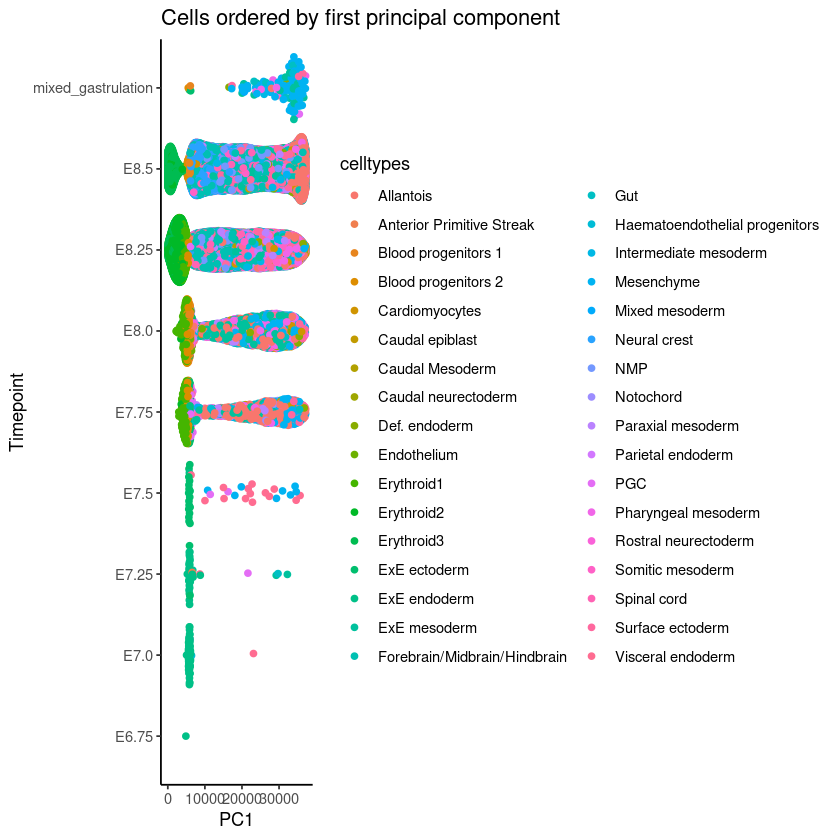

In [131]:
# PCA is a simple approach and can be good to compare to more complex algorithms 
# designed to capture differentiation processes. As a simple measure of pseudotime 
# we can use the coordinates of PC1.
# Plot PC1 vs cell_type2. 
sce$pseudotime_PC1 <- rank(sce$PC1)  # rank cells by their PC1 score
ggplot(as.data.frame(colData(sce)), aes(x = pseudotime_PC1, y = stage, 
                                             colour = celltypes)) +
    geom_quasirandom(groupOnX = FALSE) +
    scale_fill_manual(values=mycolors) + theme_classic() +
    xlab("PC1") + ylab("Timepoint") +
    ggtitle("Cells ordered by first principal component")

In [ ]:
ggsave(paste0(out_dir, "/pseudotime_PC1.png"))

In [ ]:
#  Prepare a counts matrix with labeled rows and columns. 
deng <- logcounts(sce)  # access log-transformed counts matrix
cellLabels <- sce$cell_type2 #change here to stages
colnames(deng) <- cellLabels

In [ ]:
# Make a diffusion map.
dm <- DiffusionMap(t(sce))

In [ ]:
# Optional: Try different sigma values when making diffusion map.

# dm <- DiffusionMap(t(deng), sigma = "local")  # use local option to set sigma
# sigmas <- find_sigmas(t(deng), verbose = FALSE)  # find optimal sigma
# dm <- DiffusionMap(t(deng), sigma = optimal_sigma(sigmas))  

In [ ]:
# Plot diffusion component 1 vs diffusion component 2 (DC1 vs DC2). 
tmp <- data.frame(DC1 = eigenvectors(dm)[, 1],
                  DC2 = eigenvectors(dm)[, 2],
                  Timepoint = sce$cell_type2) #change here cell stages
ggplot(tmp, aes(x = DC1, y = DC2, colour = Timepoint)) +
    geom_point() + scale_color_tableau() + 
    xlab("Diffusion component 1") + 
    ylab("Diffusion component 2") +
    theme_classic()

In [ ]:
# Next, let us use the first diffusion component (DC1) as a measure of pseudotime.
# How does the separation by cell stage look?

sce$pseudotime_diffusionmap <- rank(eigenvectors(dm)[,1])    # rank cells by their dpt
ggplot(as.data.frame(colData(sce)), 
       aes(x = pseudotime_diffusionmap, 
           y = cell_type2, colour = cell_type2)) + #change here cell stage
    geom_quasirandom(groupOnX = FALSE) +
    scale_color_tableau() + theme_classic() +
    xlab("Diffusion component 1 (DC1)") + ylab("Timepoint") +
    ggtitle("Cells ordered by DC1")

In [ ]:
ggsave(paste0(out_dir, "/pseudotime_DC1.png"))

In [ ]:
# Plot eigenvalues of diffusion distance matrix. How many diffusion components would you use?
# This is analagous to the PC elbow plot (scree plot) that we previously used to assess how 
# many PCs to use in downstream applications like clustering.
plot(eigenvalues(dm), ylim = 0:1, pch = 20, xlab = 'Diffusion component (DC)', ylab = 'Eigenvalue')

In [ ]:
# What happens if you run the diffusion map on the PCs? Why would one do this?
rownames(pca) <- cellLabels
dm <- DiffusionMap(pca)

# Diffusion pseudotime calculation. 
# Set index or tip of pseudotime calculation to be a zygotic cell (cell 268). 
dpt <- DPT(dm, tips = 268)

# Plot DC1 vs DC2 and color the cells by their inferred diffusion pseudotime.
# We can accesss diffusion pseudotime via dpt$dpt.
df <- data.frame(DC1 = eigenvectors(dm)[, 1], DC2 = eigenvectors(dm)[, 2], 
                 dptval = dpt$dpt, cell_type2 = sce$cell_type2) #change stage
p1 <- ggplot(df) + geom_point(aes(x = DC1, y = DC2, color = dptval))
p2 <- ggplot(df) + geom_point(aes(x = DC1, y = DC2, color = cell_type2))
p <- plot_grid(p1, p2)
p

In [ ]:
save_plot(paste0(out_dir, "/dpt_celltype.png"), p, base_height = 5, base_aspect_ratio = 2)

In [ ]:
# Plot diffusion pseudotime vs timepoint. 
# Which separates the data better, DC1 or diffusion pseudotime?
sce$pseudotime_dpt <- rank(dpt$dpt) 
ggplot(as.data.frame(colData(sce)), 
       aes(x = pseudotime_dpt, 
           y = cell_type2, colour = cell_type2)) + #change here cell stage
    geom_quasirandom(groupOnX = FALSE) +
    scale_color_tableau() + theme_classic() +
    xlab("Diffusion map pseudotime (dpt)") +
    ylab("Timepoint") +
    ggtitle("Cells ordered by diffusion map pseudotime")

In [ ]:
ggsave(paste0(out_dir, "/pseudotime_dpt.png"))

In [ ]:
# Save current progress.
save(sce, file = Rda.destiny.path)
# To load the data, run the following command.
load(Rda.destiny.path)